<a href="https://colab.research.google.com/github/Vane-UNCP/tecemer-lab1/blob/main/SEMANA6/Ejercicio_05_Entrenamiento_Ajuste_Hiperparametros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 5 — Entrenamiento y Ajuste de Hiperparámetros
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Usa el dataset **Digits** de `scikit-learn` (1,797 imágenes pequeñas de dígitos manuscritos, 8×8 píxeles) — incluido en la librería, sin descargas.

**Objetivo:** entender, de forma visual, el efecto de los hiperparámetros más importantes del entrenamiento (tasa de aprendizaje, tamaño de lote, número de épocas, regularización) y las técnicas para diagnosticar y corregir sobreajuste (overfitting) y subajuste (underfitting).

Framework: **TensorFlow/Keras**.

## 0. Configuración inicial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Cargar los datos

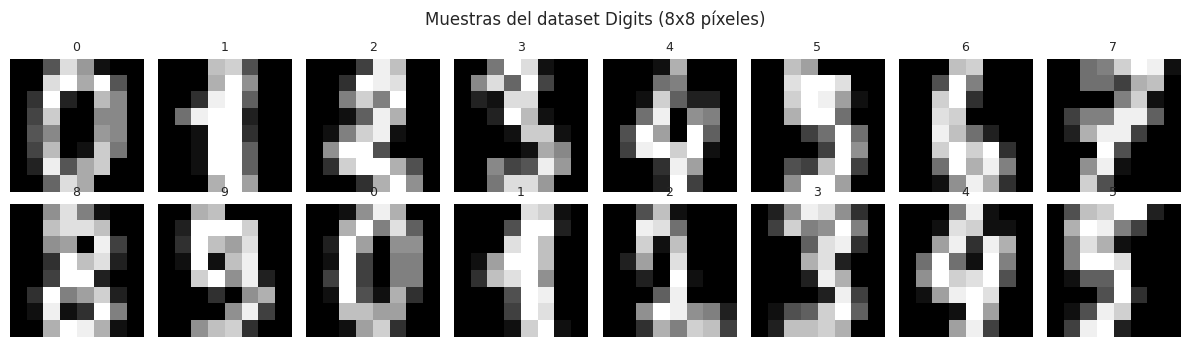

Forma de X: (1797, 64)  Clases: [0 1 2 3 4 5 6 7 8 9]


In [2]:
digitos = load_digits()
X, y = digitos.data, digitos.target

fig, ejes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(ejes.flat):
    ax.imshow(digitos.images[i], cmap="gray")
    ax.set_title(str(y[i]), fontsize=9)
    ax.axis("off")
plt.suptitle("Muestras del dataset Digits (8x8 píxeles)")
plt.tight_layout()
plt.show()

print("Forma de X:", X.shape, " Clases:", np.unique(y))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_test = escalador.transform(X_test)
print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

def construir_modelo(unidades_ocultas=32, tasa_aprendizaje=1e-3, dropout=0.0):
    modelo = keras.Sequential([
        layers.Input(shape=(64,)),
        layers.Dense(unidades_ocultas, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(unidades_ocultas, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

Entrenamiento: 1257 muestras | Prueba: 540 muestras


## 2. Tasa de aprendizaje (learning rate)

Controla **qué tan grande** es cada paso de ajuste de los pesos. Demasiado baja: el entrenamiento es lentísimo. Demasiado alta: el entrenamiento puede oscilar o divergir sin converger nunca.

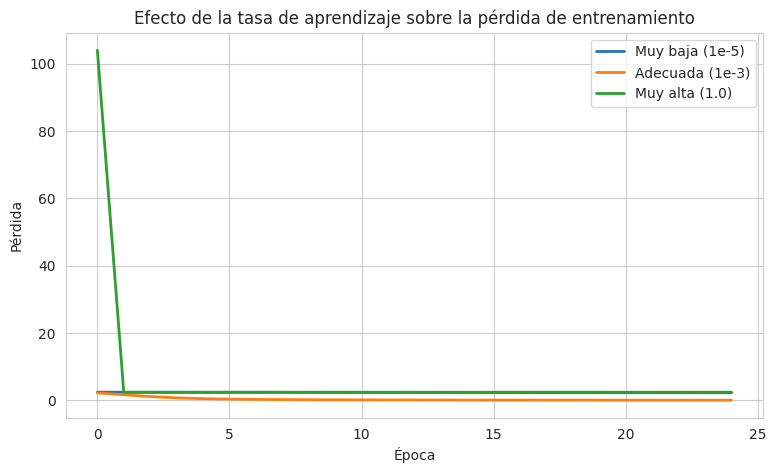

In [4]:
tasas_aprendizaje = {"Muy baja (1e-5)": 1e-5, "Adecuada (1e-3)": 1e-3, "Muy alta (1.0)": 1.0}
resultados_lr = {}

for nombre, lr in tasas_aprendizaje.items():
    modelo = construir_modelo(tasa_aprendizaje=lr)
    hist = modelo.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, verbose=0)
    resultados_lr[nombre] = hist.history["loss"]

plt.figure(figsize=(9, 5))
for nombre, perdidas in resultados_lr.items():
    plt.plot(perdidas, label=nombre, linewidth=2)
plt.title("Efecto de la tasa de aprendizaje sobre la pérdida de entrenamiento")
plt.xlabel("Época"); plt.ylabel("Pérdida"); plt.legend()
plt.show()

**Lectura esperada:** la curva "muy baja" apenas desciende (aprende demasiado lento); la curva "adecuada" desciende de forma estable; la curva "muy alta" puede oscilar violentamente o no bajar en absoluto (el optimizador "salta" de un lado a otro sin asentarse en un mínimo).

## 3. Tamaño de lote (batch size)

Cuántas muestras se procesan antes de actualizar los pesos una vez. Lotes pequeños: actualizaciones más ruidosas pero más frecuentes. Lotes grandes: actualizaciones más estables pero menos frecuentes (y requieren más memoria).

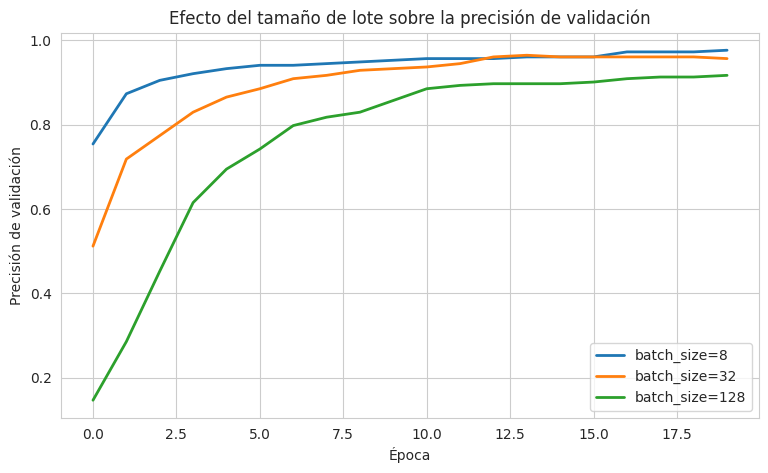

In [5]:
tamaños_lote = [8, 32, 128]
resultados_batch = {}

for tam in tamaños_lote:
    modelo = construir_modelo()
    hist = modelo.fit(X_train, y_train, epochs=20, batch_size=tam, validation_split=0.2, verbose=0)
    resultados_batch[f"batch_size={tam}"] = hist.history["val_accuracy"]

plt.figure(figsize=(9, 5))
for nombre, precision in resultados_batch.items():
    plt.plot(precision, label=nombre, linewidth=2)
plt.title("Efecto del tamaño de lote sobre la precisión de validación")
plt.xlabel("Época"); plt.ylabel("Precisión de validación"); plt.legend()
plt.show()

## 4. Sobreajuste (overfitting) provocado deliberadamente

Usamos un **subconjunto pequeño** de datos y un modelo **grande**, sin ninguna técnica de regularización — la receta perfecta para memorizar en lugar de generalizar.

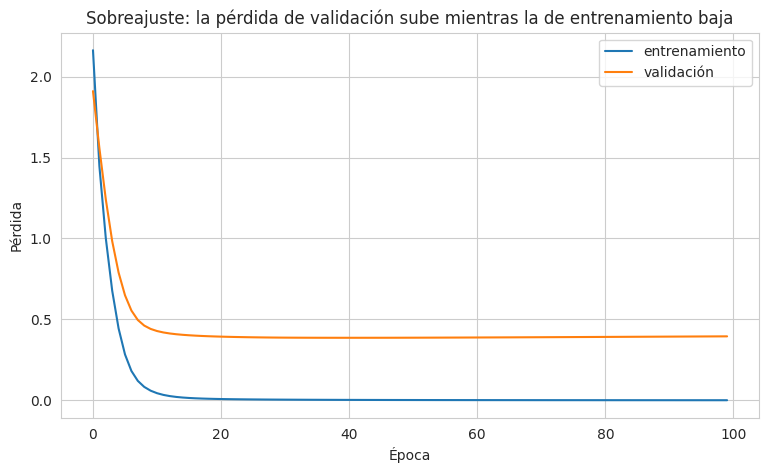

In [6]:
X_pequeno, y_pequeno = X_train[:120], y_train[:120]

modelo_sobreajustado = construir_modelo(unidades_ocultas=256, tasa_aprendizaje=1e-3)
historial_sin_es = modelo_sobreajustado.fit(
    X_pequeno, y_pequeno, epochs=100, validation_data=(X_test, y_test), verbose=0,
)

plt.figure(figsize=(9, 5))
plt.plot(historial_sin_es.history["loss"], label="entrenamiento")
plt.plot(historial_sin_es.history["val_loss"], label="validación")
plt.title("Sobreajuste: la pérdida de validación sube mientras la de entrenamiento baja")
plt.xlabel("Época"); plt.ylabel("Pérdida"); plt.legend()
plt.show()

**Diagnóstico visual de sobre/subajuste:**
- **Sobreajuste (overfitting)**: la pérdida de entrenamiento sigue bajando, pero la de validación empieza a subir — el modelo memoriza detalles específicos del conjunto de entrenamiento que no generalizan.
- **Subajuste (underfitting)**: ambas curvas se quedan altas y no mejoran — el modelo es demasiado simple (o se entrenó muy poco) para capturar el patrón.

## 5. Corrección 1 — EarlyStopping

Detiene el entrenamiento automáticamente cuando la pérdida de validación deja de mejorar, y puede restaurar los pesos del mejor punto observado.

Entrenamiento detenido en la época 35 de 100 programadas.


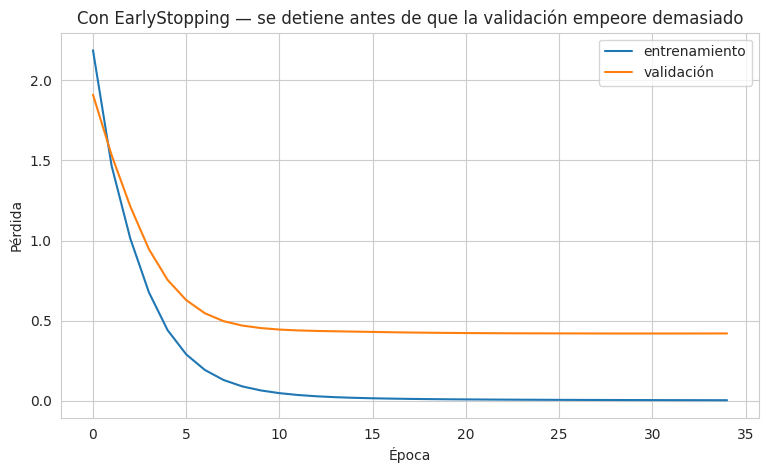

In [7]:
modelo_con_es = construir_modelo(unidades_ocultas=256, tasa_aprendizaje=1e-3)
parada_temprana = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

historial_con_es = modelo_con_es.fit(
    X_pequeno, y_pequeno, epochs=100, validation_data=(X_test, y_test),
    callbacks=[parada_temprana], verbose=0,
)

print(f"Entrenamiento detenido en la época {len(historial_con_es.history['loss'])} de 100 programadas.")

plt.figure(figsize=(9, 5))
plt.plot(historial_con_es.history["loss"], label="entrenamiento")
plt.plot(historial_con_es.history["val_loss"], label="validación")
plt.title("Con EarlyStopping — se detiene antes de que la validación empeore demasiado")
plt.xlabel("Época"); plt.ylabel("Pérdida"); plt.legend()
plt.show()

## 6. Corrección 2 — Dropout

`Dropout` apaga aleatoriamente una fracción de neuronas en cada paso de entrenamiento, obligando a la red a no depender excesivamente de ninguna neurona individual.

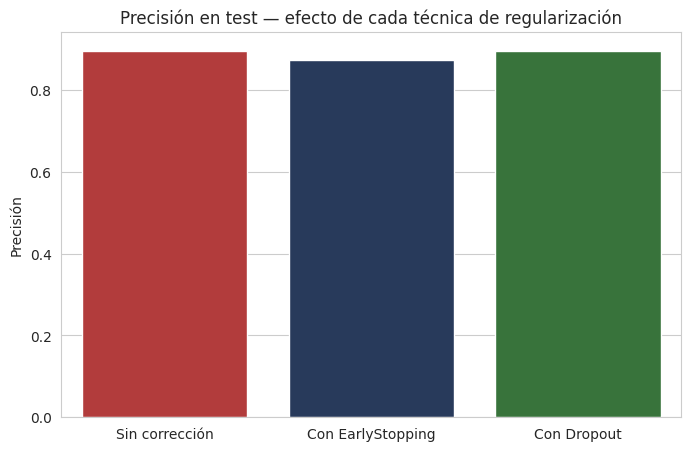

In [8]:
modelo_con_dropout = construir_modelo(unidades_ocultas=256, tasa_aprendizaje=1e-3, dropout=0.5)
historial_dropout = modelo_con_dropout.fit(
    X_pequeno, y_pequeno, epochs=100, validation_data=(X_test, y_test), verbose=0,
)

_, precision_sin = modelo_sobreajustado.evaluate(X_test, y_test, verbose=0)
_, precision_es = modelo_con_es.evaluate(X_test, y_test, verbose=0)
_, precision_dropout = modelo_con_dropout.evaluate(X_test, y_test, verbose=0)

plt.figure(figsize=(8, 5))
sns.barplot(x=["Sin corrección", "Con EarlyStopping", "Con Dropout"],
            y=[precision_sin, precision_es, precision_dropout],
            hue=["Sin corrección", "Con EarlyStopping", "Con Dropout"],
            palette=["#C62828", "#1F3864", "#2E7D32"], legend=False)
plt.title("Precisión en test — efecto de cada técnica de regularización")
plt.ylabel("Precisión")
plt.show()

## 7. Búsqueda de hiperparámetros: mapa de calor

Cuando hay más de un hiperparámetro a ajustar, una forma simple de explorar combinaciones es una **búsqueda en grilla** (grid search) manual, visualizada como mapa de calor.

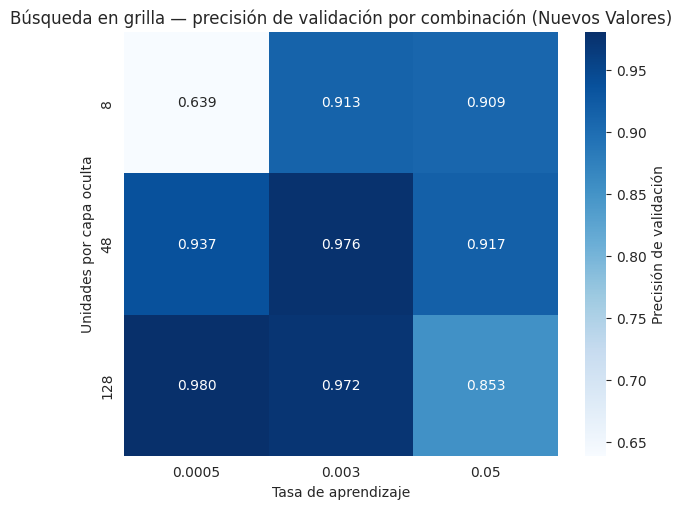

Mejor combinación: unidades=128, lr=0.0005 -> precisión=0.980


In [9]:
opciones_unidades = [8, 48, 128]
opciones_lr = [5e-4, 3e-3, 5e-2]

matriz_resultados = np.zeros((len(opciones_unidades), len(opciones_lr)))

for i, unidades in enumerate(opciones_unidades):
    for j, lr in enumerate(opciones_lr):
        modelo = construir_modelo(unidades_ocultas=unidades, tasa_aprendizaje=lr)
        hist = modelo.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=0)
        matriz_resultados[i, j] = hist.history["val_accuracy"][-1]

plt.figure(figsize=(7, 5.5))
sns.heatmap(matriz_resultados, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=opciones_lr, yticklabels=opciones_unidades, cbar_kws={"label": "Precisión de validación"})
plt.xlabel("Tasa de aprendizaje"); plt.ylabel("Unidades por capa oculta")
plt.title("Búsqueda en grilla — precisión de validación por combinación (Nuevos Valores)")
plt.show()

mejor_i, mejor_j = np.unravel_index(np.argmax(matriz_resultados), matriz_resultados.shape)
print(f"Mejor combinación: unidades={opciones_unidades[mejor_i]}, "
      f"lr={opciones_lr[mejor_j]} -> precisión={matriz_resultados[mejor_i, mejor_j]:.3f}")

## 8. Resumen

| Hiperparámetro | Efecto si es muy bajo | Efecto si es muy alto |
|---|---|---|
| Tasa de aprendizaje | Entrenamiento lentísimo, puede no converger a tiempo | Oscilación o divergencia — nunca converge |
| Tamaño de lote | Actualizaciones ruidosas, entrenamiento lento por época | Menos actualizaciones por época, más memoria requerida |
| Épocas (sin EarlyStopping) | Subajuste (el modelo no terminó de aprender) | Sobreajuste (el modelo memoriza el ruido) |
| Unidades por capa | Subajuste (poca capacidad) | Sobreajuste (demasiada capacidad para pocos datos) |
| Dropout | Poca protección contra sobreajuste | Subajuste (se apaga demasiada información) |

El ajuste de hiperparámetros **no tiene una fórmula única** — es un proceso experimental guiado por estas visualizaciones: se observan las curvas, se diagnostica el problema (sobre/subajuste) y se aplica la corrección correspondiente.
